In [1]:
print("svm for traffic classification")


svm for traffic classification


In [14]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from joblib import dump, load
import os
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support

In [15]:
# File paths
data_path = "/content/drive/My Drive/xapp_data/"
df0 = pd.read_csv(data_path + "ue0.csv")  # URLLC dataset
df1 = pd.read_csv(data_path + "ue1.csv")  # URLLC dataset2
df2 = pd.read_csv(data_path + "ue2.csv")  # eMBB dataset
df3 = pd.read_csv(data_path + "ue3.csv")  # mMTC dataset

model_path = data_path + "svm_model.pkl" # this is for the svm model
encoder_path = data_path + "label_encoder.pkl"
plot_path = data_path + "svm_accuracy.png"


# Assignment of the labels
df0["label"] = "URLLC"
df1["label"] = "URLLC"
df2["label"] = "eMBB"
df3["label"] = "mMTC"

In [16]:
df = pd.concat([df0, df1, df2, df3], ignore_index=True)

In [17]:
class SVM:
    def __init__(self):
        self.model = None
        self.encoder = LabelEncoder()
        self.X_train = self.X_test = self.y_train = self.y_test = None
        self.features = []

    def preprocessing(self, df):
        df = df.drop(columns=['timestamp', 'granulperiod'], errors='ignore')
        df = df.dropna()
        self.features = [col for col in df.columns if col != 'label']
        X = df[self.features]
        y = self.encoder.fit_transform(df['label'])
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

    def train(self):
        self.model = SVC(kernel='rbf', probability=True)
        self.model.fit(self.X_train, self.y_train)
        return self.model

    def store_in_pickle_file(self, model_path, encoder_path):
        dump(self.model, model_path)
        dump(self.encoder, encoder_path)

    def retrieve_from_pickle_file(self, model_path, encoder_path):
        self.model = load(model_path)
        self.encoder = load(encoder_path)

    def predict(self, model, data):
        prediction = model.predict([data])
        return self.encoder.inverse_transform(prediction)[0]

    def visualize_accuracy(self, plot_path):
      y_pred = self.model.predict(self.X_test)
      cm = confusion_matrix(self.y_test, y_pred)
      cm_df = pd.DataFrame(cm, index=self.encoder.classes_, columns=self.encoder.classes_)

      plt.figure(figsize=(6, 4))
      sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
      plt.title("Confusion Matrix")
      plt.ylabel("Actual")
      plt.xlabel("Predicted")
      plt.tight_layout()
      plt.savefig(plot_path)
      plt.show()

      print("\n Confusion Matrix:")
      display(cm_df)  # Only in Colab/Jupyter

    def classification_report(self):
        y_pred = self.model.predict(self.X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(self.y_test, y_pred, average=None)
        report_df = pd.DataFrame({
            "Class": self.encoder.classes_,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

        print("\n Classification Report:")
        display(report_df.round(2))  # Only in Colab/Jupyter
        return report_df


 Classification Report:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Class,Precision,Recall,F1-Score
0,URLLC,0.56,1.0,0.72
1,eMBB,1.00,0.2,0.33
2,mMTC,0.00,0.0,0.00


   Class  Precision  Recall  F1-Score
0  URLLC   0.556465     1.0  0.715037
1   eMBB   1.000000     0.2  0.333333
2   mMTC   0.000000     0.0  0.000000


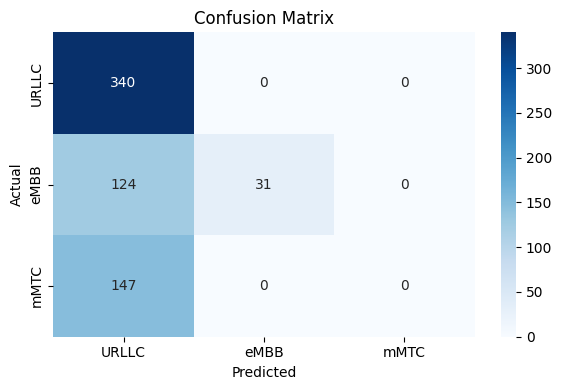


 Confusion Matrix:


,URLLC,eMBB,mMTC
URLLC,340,0,0
eMBB,124,31,0
mMTC,147,0,0


In [18]:
svm_classifier = SVM()
svm_classifier.preprocessing(df)
svm_classifier.train()
svm_classifier.store_in_pickle_file(model_path, encoder_path)
print(svm_classifier.classification_report())
svm_classifier.visualize_accuracy(plot_path)

In [2]:
from google.colab import files
uploaded = files.upload()


Saving svm.pkl to svm.pkl


In [3]:
import pickle

with open('svm.pkl', 'rb') as f:
    svm_model = pickle.load(f)


In [5]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
data_path = "/content/drive/My Drive/xapp_data/"


In [7]:
df0 = pd.read_csv(data_path + "ue0.csv")
df1 = pd.read_csv(data_path + "ue1.csv")
df2 = pd.read_csv(data_path + "ue2.csv")
df3 = pd.read_csv(data_path + "ue3.csv")


In [8]:
model_path = data_path + "svm_model.pkl"
encoder_path = data_path + "label_encoder.pkl"
plot_path = data_path + "svm_accuracy.png"
